# Day 4 — Activations, Gradients, BatchNorm (makemore Part 3, 1h55m)
Lecture names used (n_embd, n_hidden, block_size, vocab_size). Init fixes + BatchNorm + Linear/BatchNorm1d/Tanh classes = my exercises. Starting network is deliberately pre-fix.

In [229]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [230]:
# BOILERPLATE: data + maps + split
words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

block_size = 3

def build_dataset(word_list):
    X, Y = [], []
    for w in word_list:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])
print(Xtr.shape, Xdev.shape, Xte.shape)

torch.Size([182625, 3]) torch.Size([22655, 3]) torch.Size([22866, 3])


In [231]:
# starting network — NAIVE init (the video's fixes are my exercise)
n_embd = 10
n_hidden = 200

gain = 5/3 # due to using tanh, https://docs.pytorch.org/docs/2.13/nn.init.html
kaiming_init_scale = gain/((n_embd * block_size)**0.5)

bngain = torch.ones((1, n_hidden)) # γ, https://arxiv.org/pdf/1502.03167
bnbias = torch.zeros((1, n_hidden)) # β, https://arxiv.org/pdf/1502.03167

bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * kaiming_init_scale # before * 0.1 now, kaiming_init_scale
# b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

parameters = [C, W1, W2, b2, bnbias, bngain]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12097


In [232]:
# BOILERPLATE: optimization loop (use small max_steps during the surgery phase)
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 # + b1

    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

    hpreact = (hpreact - bnmean)/(bnstd)
    hpreact = bngain * (hpreact) + bnbias

    with torch.no_grad():
        bnmean_running = bnmean_running * 0.999 + bnmean * 0.001
        bnstd_running = bnstd_running * 0.999 + bnstd * 0.001

    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3239
  10000/ 200000: 2.0322
  20000/ 200000: 2.5675
  30000/ 200000: 2.0125
  40000/ 200000: 2.2446
  50000/ 200000: 1.8897
  60000/ 200000: 2.0785
  70000/ 200000: 2.3681
  80000/ 200000: 2.2918
  90000/ 200000: 2.0238
 100000/ 200000: 2.3673
 110000/ 200000: 2.3132
 120000/ 200000: 1.6414
 130000/ 200000: 1.9311
 140000/ 200000: 2.2231
 150000/ 200000: 2.0027
 160000/ 200000: 2.0997
 170000/ 200000: 2.4949
 180000/ 200000: 2.0199
 190000/ 200000: 2.1707


In [233]:
hpreact.shape

torch.Size([32, 200])

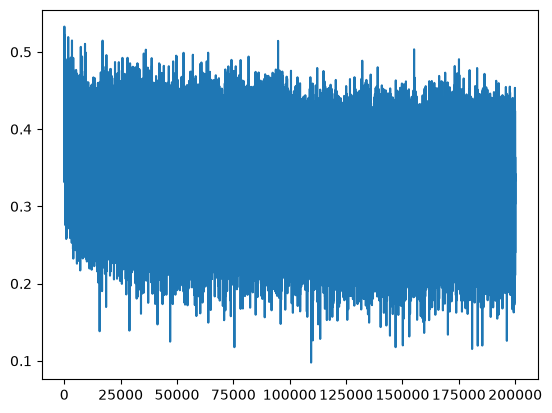

In [234]:
plt.plot(lossi)

In [235]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'dev':   (Xdev, Ydev),
        'test':  (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 # + b1
    hpreact = bngain * ((hpreact - bnmean_running)/bnstd_running) + bnbias
    h = hpreact.tanh()
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('dev')

train 2.0674145221710205
dev 2.1056840419769287


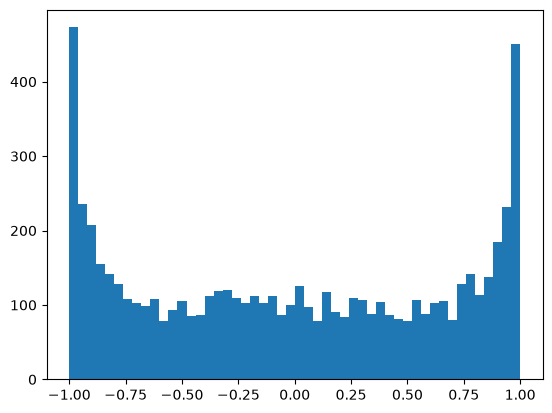

In [236]:
# BOILERPLATE (segment viz, from the lecture): distribution of h — where do activations live?
plt.hist(h.view(-1).tolist(), 50);

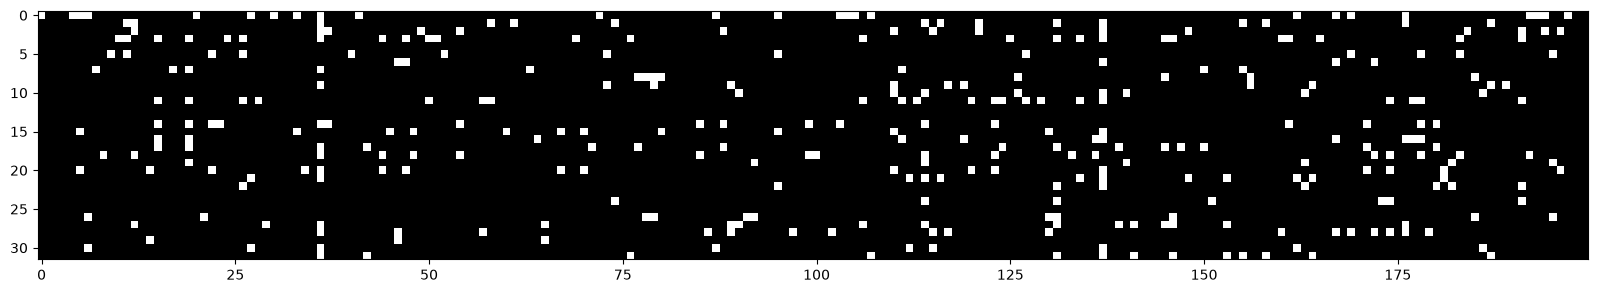

In [237]:
# BOILERPLATE (segment viz, from the lecture): saturation map — white = |h| > 0.99 (dead-ish)
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In [238]:
a = torch.zeros(27).float()
y = torch.tensor(1)
loss = F.cross_entropy(a, y)
loss

tensor(3.2958)

## observations — naive init, 200k run

- first loss 27.88 (same as karpathy), should be ~3.29. confidently wrong at init, same as my 21.9 thing before
- loss curve = hockey stick, early steps wasted just fixing the init
- still ended at train 2.1268 / dev 2.1698 tho. bad init didnt kill it, just wasted time (shallow net, deep would die)
- h histogram = two towers at ±1, saturated
- saturation map has a lot of white, those units have grad ~0
- derived the ideal init loss with a toy: cross_entropy(zeros(27), y) = -log(1/27) = **3.2958**. so logits should start ~0 -> OUTPUT layer (w2, b2) near 0. hidden layers dont get this, they need proper scale or signal dies

## observations — logits fix (w2 * 0.01, b2 = 0)

- step 0 loss: **3.3221**, basically the ideal 3.2958. no more hockey stick
- w2 was most of the issue (overconfidence). b2=0 didnt contribute much for this small nn but may come in handy later
- final: train 2.0696 / dev **2.1311** — better than naive's, the un-wasted early steps actually helped. also beats my part2 best (2.1678) lol
- W1 still naive -> tanh still saturated, thats next

## observations — tanh fix (w1 * 0.1, hand tuned)

- shrunk w1 by eye watching the histogram, towers at ±1 melted. kaiming formula says (5/3)/sqrt(30) ≈ 0.30, my 0.1 is smaller but works — exact number is forgiving here
- step 0: 3.3197, still ideal-ish
- final: train 2.0453 / dev **2.1037** — new best again. 3 fixes, 3 improvements: 2.1698 -> 2.1311 -> 2.1037
- clean rerun with b1 * 0.1 (bias was std 1, louder than the w1*0.1 signal at ~0.55 — scaled it down): step 0 3.3084, train 2.0613 / dev 2.1134. slightly worse than the 2.1037 run = run to run noise, ±0.01 doesnt mean anything here

## observations — kaiming init (no more hardcoding)

- from the pytorch docs: tanh gain = 5/3. fan_in for w1 = 30 = n_embd * block_size (3 chars x 10 dims flattened, = embcat's width)
- kaiming_init_scale = (5/3)/sqrt(30) ≈ 0.304, vs my hand tuned 0.1
- b1 * 0.01 now too
- step 0: 3.3179. final: train 2.0377 / dev **2.1070** — same as hand tuned (2.1134) within noise. the formula's win isnt a better number, its not needing the histogram eyeballing, works at any depth

## observations — batchnorm (by hand)

- implemented the paper's algorithm 1: batch mean/std over dim 0 keepdim, normalize, then bngain (γ) * x̂ + bnbias (β). gain=ones, bias=zeros so it starts as a pure standardizer
- BUG 1: divided by bnstd**2 = dividing by variance not std (symbol collision, paper says σ² but my var was already std). caught it with the contract check: post-normalize std(0) should be all 1s, wasnt. sneaky part: it still trained fine cause bngain just learned to absorb the wrong scale. accidentally-working again
- BUG 2 (hit it before watching the fix): trained w/ BN then split_loss showed train 2.98/dev 3.01 = garbage. eval forward had no BN + deeper problem: batch stats dont exist at eval (whats the std of 1 sample?). thats what the running stats are for
- running stats: bnmean_running (init zeros), bnstd_running (init ones), updated in no_grad with 0.999/0.001 momentum. NOT in parameters — buffers, not trained. i had the inits swapped at first (mean=ones/std=zeros), works after 200k anyway cause 0.999^200k kills the init. fixed for principle
- killed b1: mean subtraction cancels it, bnbias is its replacement. 12297 -> 12097 params
- final full run: **train 2.0666 / dev 2.1052** — same as kaiming-only (2.1070). BN didnt buy loss on this shallow well-init'd net, it buys insurance: could delete all the init care and still train, and it matters at depth. matching-not-beating is the expected result here

## observations — batchnorm

- implemented the paper's algorithm 1: batch mean/std over dim 0 (per neuron stats, keepdim), normalize, then bngain * x + bnbias. gain/bias are trainable (in parameters), start at ones/zeros = identity
- BUG 1: divided by bnstd**2 = variance not std. contract check (normalized std should be ~1) caught it. interesting: training looked fine anyway because bngain just learned to absorb the wrong scale. learnable rescaling hides bugs
- hit the eval problem MYSELF: split_loss scored 2.98/3.01 garbage after healthy training — its forward had no BN, and even with BN, what mean/std do you use? batch of 1 in the sampler has no std. thats why running stats exist
- running stats: bnmean_running/bnstd_running buffers (NOT in parameters, no grads, updated in no_grad with 0.999/0.001 momentum). BUG 2: initialized them swapped (mean=ones, std=zeros) — long run hides it since 0.999^200k ~ 0
- killed b1: mean subtraction cancels it, was dead weight. 12097 params now
- final with BN: train 2.0666 / dev **2.1052** — same as kaiming-only (2.1070) within noise. BN doesnt buy loss on a shallow well-inited net, it buys insurance: could delete all the init care and still train, and it holds distributions at depth where init cant

## part 2 — pytorchify (BOILERPLATE: classes repackage what i built by hand. gate: point at each BatchNorm1d line and name the line of MY loop it came from. real exercise = the experiments + reading the plots)

In [239]:
# Let's train a deeper network
# The classes we create here are the same API as nn.Module in PyTorch

class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd),            generator=g)
layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]
layers = [
  Linear(n_embd * block_size, n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size),
]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].gamma *= 0.1
  # layers[-1].weight *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 1 #5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

AttributeError: 'Linear' object has no attribute 'gamma'

In [ ]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function

  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 1.0 # 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if i >= 1000:
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.2962


layer 1 (      Tanh): mean -0.04, std 0.76, saturated: 21.97%
layer 3 (      Tanh): mean -0.01, std 0.72, saturated: 11.00%
layer 5 (      Tanh): mean +0.01, std 0.73, saturated: 13.00%
layer 7 (      Tanh): mean -0.05, std 0.73, saturated: 13.34%
layer 9 (      Tanh): mean +0.00, std 0.72, saturated: 10.53%


Text(0.5, 1.0, 'activation distribution')

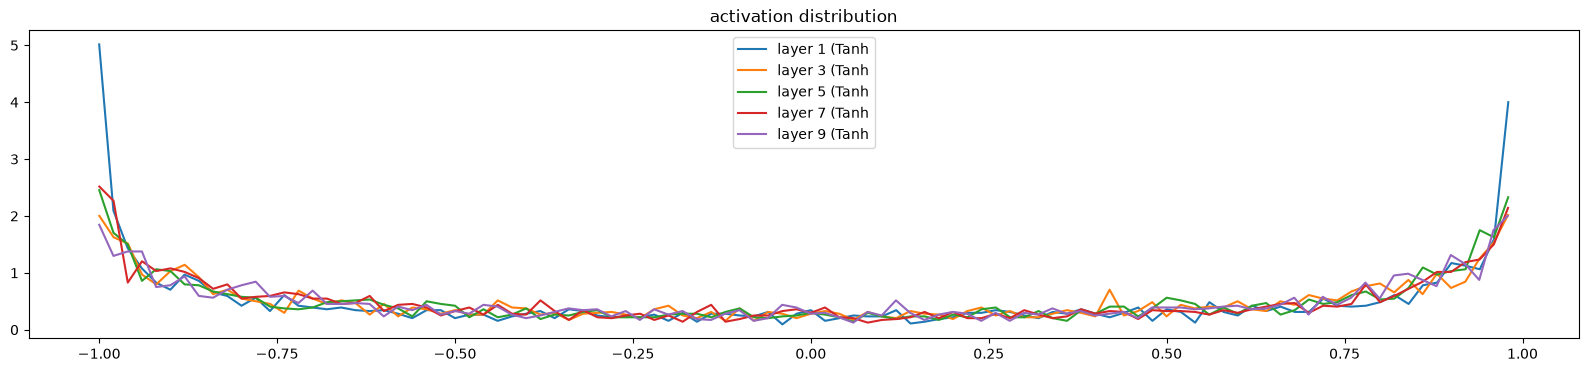

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 1 (      Tanh): mean +0.000024, std 3.353991e-03
layer 3 (      Tanh): mean +0.000012, std 3.157343e-03
layer 5 (      Tanh): mean -0.000004, std 2.925862e-03
layer 7 (      Tanh): mean +0.000036, std 2.715700e-03
layer 9 (      Tanh): mean +0.000020, std 2.308167e-03


Text(0.5, 1.0, 'gradient distribution')

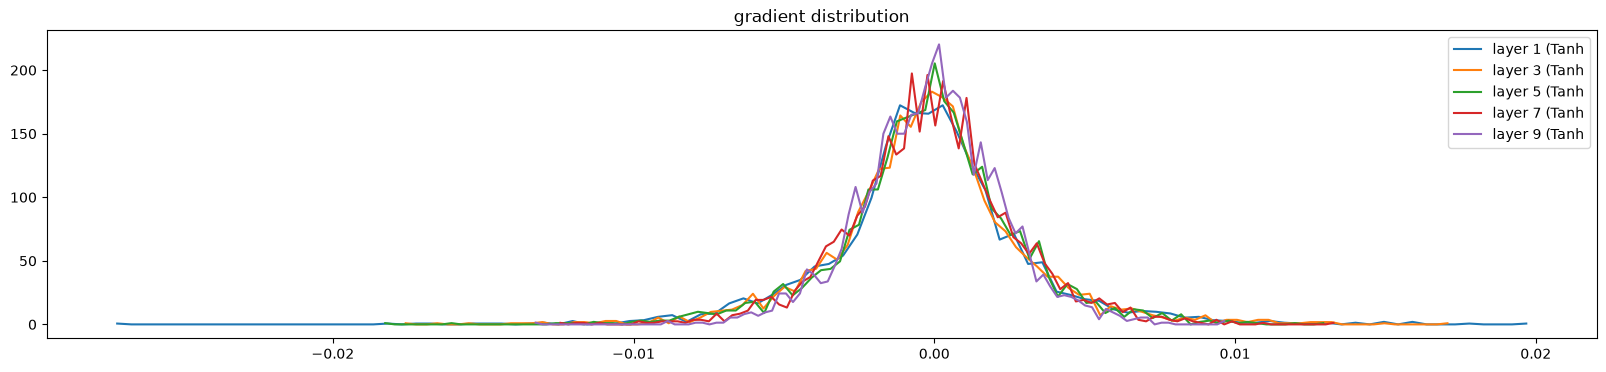

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000980 | std 1.189170e-02 | grad:data ratio 1.189149e-02
weight  (30, 100) | mean +0.000118 | std 1.005290e-02 | grad:data ratio 3.214555e-02
weight (100, 100) | mean +0.000033 | std 7.821211e-03 | grad:data ratio 4.653361e-02
weight (100, 100) | mean -0.000107 | std 6.655620e-03 | grad:data ratio 3.925851e-02
weight (100, 100) | mean -0.000017 | std 6.086040e-03 | grad:data ratio 3.605767e-02
weight (100, 100) | mean -0.000077 | std 5.075620e-03 | grad:data ratio 3.015269e-02
weight  (100, 27) | mean -0.000000 | std 2.056585e-02 | grad:data ratio 2.909911e-01


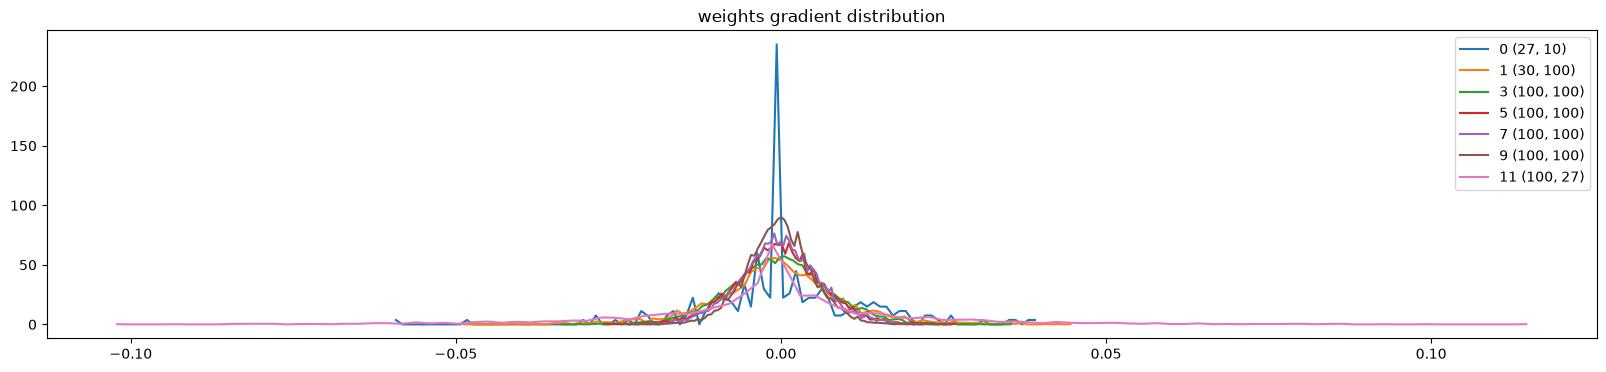

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

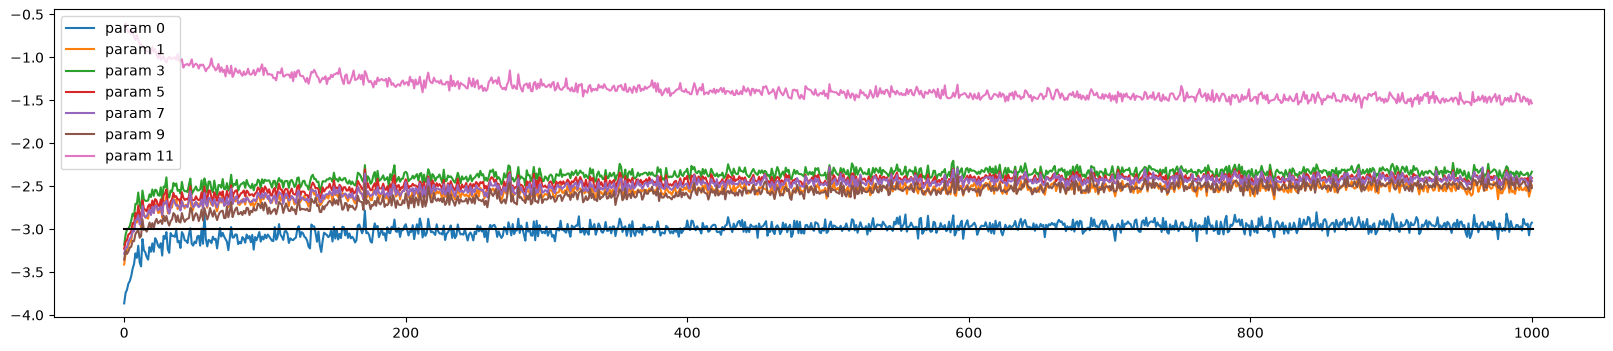

In [ ]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [ ]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 2.366689682006836
val 2.374152183532715


In [ ]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

carplie.
arlilli.
kimrix.
taty.
sacansye.
rahnen.
den.
art.
areli.
neroniahceriiv.
kaleigy.
ham.
jorriqsijahsroine.
fvin.
quiroelogiearyrix.
kaeelinsan.
edre.
iia.
gile.
jasri.
